<a href="https://colab.research.google.com/github/auroraadiswari/Semantic-Recommendation-System-using-Transformer/blob/main/sistem_rekomendasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instalasi dan Import Library

In [ ]:
# Install library yang dibutuhkan (Jalankan sel ini sekali saja)
!pip install kagglehub pandas sentence-transformers scikit-learn

import pandas as pd
import kagglehub
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Library berhasil diimpor!")

Library berhasil diimpor!


#Mengunduh dan Memuat Dataset

In [ ]:
# 1. Download seluruh file dataset dari Kaggle
print("Mengunduh dataset dari Kaggle...")
path = kagglehub.dataset_download("hernan4444/anime-recommendation-database-2020")
print(f"Path dataset: {path}")

# 2. Memuat file CSV
print("Memuat file CSV...")
synopsis_df = pd.read_csv(f"{path}/anime_with_synopsis.csv")
anime_df = pd.read_csv(f"{path}/anime.csv")


# 3. Merging (Menggabungkan) dataset
# Kita ambil MAL_ID, Studios, dan Type dari anime.csv, lalu gabungkan ke synopsis_df
print("Melakukan merging dataset...")
df = pd.merge(synopsis_df, anime_df[['MAL_ID', 'Studios', 'Type']], on='MAL_ID', how='left')

# Menampilkan total jumlah data (baris) dan fitur (kolom)
jumlah_baris = df.shape[0]
jumlah_kolom = df.shape[1]

print(f"Total judul anime (baris data): {jumlah_baris}")
print(f"Total atribut (kolom data): {jumlah_kolom}")

# Tampilkan 3 data teratas untuk memastikan proses merge berhasil
df.head(3)

Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'anime-recommendation-database-2020' dataset.
Path dataset: /kaggle/input/anime-recommendation-database-2020
Memuat file CSV...
Melakukan merging dataset...
Total judul anime (baris data): 16214
Total atribut (kolom data): 7


,MAL_ID,Name,Score,Genres,sypnopsis,Studios,Type
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever...",Sunrise,TV
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ...",Bones,Movie
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0...",Madhouse,TV


#Pra-pemrosesan dan Fusi Metadata (Knowledge Fusion)

In [ ]:
# 1. Menyeragamkan nama kolom
df = df.rename(columns={'sypnopsis': 'Synopsis'})

# 2. Menangani Missing Values (Data Kosong)
df['Synopsis'] = df['Synopsis'].fillna('No synopsis available')
df['Genres'] = df['Genres'].fillna('Unknown Genre')
df['Studios'] = df['Studios'].fillna('Unknown Studio')
df['Type'] = df['Type'].fillna('Unknown Type')

# 3. Fungsi untuk Fusi Metadata
def fuse_knowledge(row):
    genre_text = f"[GENRE] {row['Genres']}"
    studio_text = f"[STUDIO] {row['Studios']}"
    type_text = f"[TYPE] {row['Type']}"
    synopsis_text = f"[SYNOPSIS] {row['Synopsis']}"

    # Menyatukan semua elemen
    return f"{genre_text} {studio_text} {type_text} {synopsis_text}"

# Terapkan fungsi ke seluruh data dan buat kolom baru
df['Fused_Text'] = df.apply(fuse_knowledge, axis=1)

print("Contoh hasil teks yang sudah difusi:")
print(df['Fused_Text'].iloc[0])

Contoh hasil teks yang sudah difusi:
[GENRE] Action, Adventure, Comedy, Drama, Sci-Fi, Space [STUDIO] Sunrise [TYPE] TV [SYNOPSIS] In the year 2071, humanity has colonized several of the planets and moons of the solar system leaving the now uninhabitable surface of planet Earth behind. The Inter Solar System Police attempts to keep peace in the galaxy, aided in part by outlaw bounty hunters, referred to as "Cowboys." The ragtag team aboard the spaceship Bebop are two such individuals. Mellow and carefree Spike Spiegel is balanced by his boisterous, pragmatic partner Jet Black as the pair makes a living chasing bounties and collecting rewards. Thrown off course by the addition of new members that they meet in their travels—Ein, a genetically engineered, highly intelligent Welsh Corgi; femme fatale Faye Valentine, an enigmatic trickster with memory loss; and the strange computer whiz kid Edward Wong—the crew embarks on thrilling adventures that unravel each member's dark and mysterious p

#Inisialisasi Model dan Ekstraksi Vektor (Embedding)

Memuat model Sentence-Transformer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sedang mengekstraksi representasi semantik ke dalam ruang vektor...


Batches:   0%|          | 0/507 [00:00<?, ?it/s]

Selesai! Ukuran matriks vektor kita: (16214, 384)

------------------------------------------------------------
CONTOH TRANSFORMASI: TEKS -> VEKTOR (EMBEDDING)
------------------------------------------------------------
1. Teks Asli Anime Pertama:
[GENRE] Action, Adventure, Comedy, Drama, Sci-Fi, Space [STUDIO] Sunrise [TYPE] TV [SYNOPSIS] In the year 2071, humanity has colonized several of the planets and moons of the solar system leaving the ...

2. Wujud Vektor (Mewakili makna teks di atas):
   - Tipe data: <class 'numpy.ndarray'>
   - Total dimensi: 384 titik koordinat
   - Cuplikan 10 nilai pertama: [-0.07526902 -0.05180899 -0.04230158 -0.03401597  0.01485617  0.03895363
  0.04022004  0.00874177  0.01248833 -0.0237944 ]

Menyiapkan visualisasi peta warna (Heatmap) vektor...


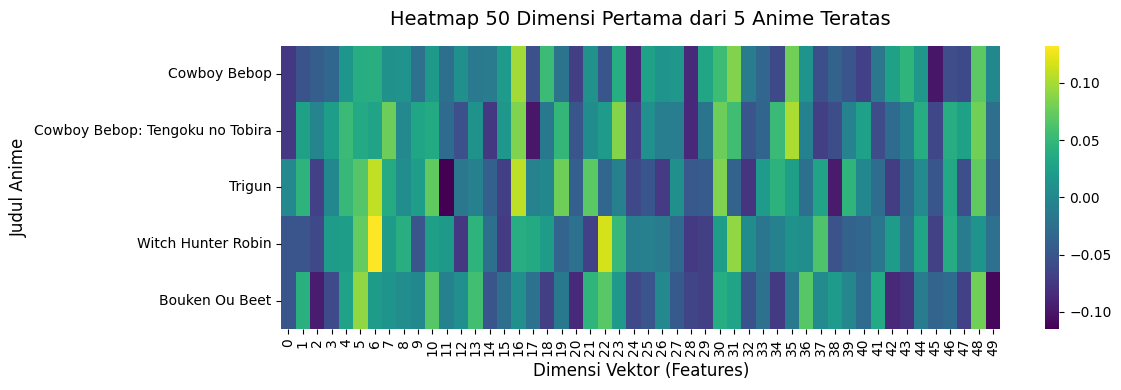

In [ ]:
# 1. Memuat model Pre-trained Transformer
print("Memuat model Sentence-Transformer...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Proses ekstraksi teks menjadi vektor (Embedding)
print("Sedang mengekstraksi representasi semantik ke dalam ruang vektor...")
embeddings = model.encode(df['Fused_Text'].tolist(), show_progress_bar=True)
print(f"Selesai! Ukuran matriks vektor kita: {embeddings.shape}\n")

# CONTOH PERUBAHAN DATA
print("-" * 60)
print("CONTOH TRANSFORMASI: TEKS -> VEKTOR (EMBEDDING)")
print("-" * 60)

# Menampilkan teks anime pertama
contoh_teks = df['Fused_Text'].iloc[0]
print(f"1. Teks Asli Anime Pertama:\n{contoh_teks[:200]}...\n")

# Menampilkan wujud vektornya
contoh_vektor = embeddings[0]
print(f"2. Wujud Vektor (Mewakili makna teks di atas):")
print(f"   - Tipe data: {type(contoh_vektor)}")
print(f"   - Total dimensi: {len(contoh_vektor)} titik koordinat")
print(f"   - Cuplikan 10 nilai pertama: {contoh_vektor[:10]}\n")


# VISUALISASI VEKTOR (HEATMAP)
print("Menyiapkan visualisasi peta warna (Heatmap) vektor...")

plt.figure(figsize=(12, 4))
# ambil 5 anime pertama, dan hanya menampilkan 50 dimensi pertama
# agar visualisasinya jelas dan tidak terlalu padat
sns.heatmap(embeddings[:5, :50], cmap="viridis", cbar=True)

plt.title("Heatmap 50 Dimensi Pertama dari 5 Anime Teratas", fontsize=14, pad=15)
plt.xlabel("Dimensi Vektor (Features)", fontsize=12)
plt.ylabel("Judul Anime", fontsize=12)

# Mengganti label sumbu Y dengan judul animenya langsung
plt.yticks(ticks=np.arange(5) + 0.5, labels=df['Name'].iloc[:5].tolist(), rotation=0)

plt.tight_layout()
plt.show()

#Membuat Fungsi Rekomendasi (Cosine Similarity)

In [ ]:
def get_semantic_recommendation(anime_title, top_n=10):
    # Cek apakah judul anime yang diketik ada di dalam dataset
    if anime_title not in df['Name'].values:
        return "Judul anime tidak ditemukan di database. Pastikan penulisan sama persis."

    # 1. Cari index/posisi baris anime yang dicari
    idx = df[df['Name'] == anime_title].index[0]

    # 2. Hitung Cosine Similarity antara anime input dengan SEMUA anime
    # embeddings[idx] adalah vektor dari anime kueri kita
    sim_scores = cosine_similarity([embeddings[idx]], embeddings)[0]

    # 3. Urutkan skor dari yang paling tinggi ke rendah
    # [-(top_n+1):-1] mengambil top_n teratas dari belakang (tidak termasuk dirinya sendiri)
    # [::-1] membalik urutannya agar dari terbesar ke terkecil
    top_indices = sim_scores.argsort()[-(top_n+1):-1][::-1]

    # 4. Ambil data anime yang direkomendasikan
    recommendations = df.iloc[top_indices][['Name', 'Genres', 'Studios', 'Type']].copy()

    # 5. manambahkan kolom Skor Kemiripan agar kita bisa melihat akurasinya
    recommendations['Similarity_Score'] = sim_scores[top_indices]

    return recommendations

print("Fungsi rekomendasi siap digunakan!")

Fungsi rekomendasi siap digunakan!


#Pengujian Sistem (Testing)

Rekomendasi teratas untuk anime: 'Death Note'

1. Judul    : Id:Invaded
   Akurasi Kemiripan : 0.6041 (60.41%)
   Genre    : Mystery, Police, Psychological, Sci-Fi
   Studio   : NAZ
----------------------------------------------------------------------
2. Judul    : Un-Go
   Akurasi Kemiripan : 0.5905 (59.05%)
   Genre    : Mystery, Supernatural
   Studio   : Bones
----------------------------------------------------------------------
3. Judul    : Koroshiya 1 The Animation: Episode 0
   Akurasi Kemiripan : 0.5857 (58.57%)
   Genre    : Action, Dementia, Drama, Horror, Martial Arts, Psychological, Seinen
   Studio   : AIC
----------------------------------------------------------------------
4. Judul    : Angel Cop
   Akurasi Kemiripan : 0.5843 (58.43%)
   Genre    : Action, Sci-Fi, Police
   Studio   : D.A.S.T.
----------------------------------------------------------------------
5. Judul    : Kara no Kyoukai 7: Satsujin Kousatsu (Go)
   Akurasi Kemiripan : 0.5788 (57.88%)
   Genre  

/tmp/ipykernel_9329/2359497748.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


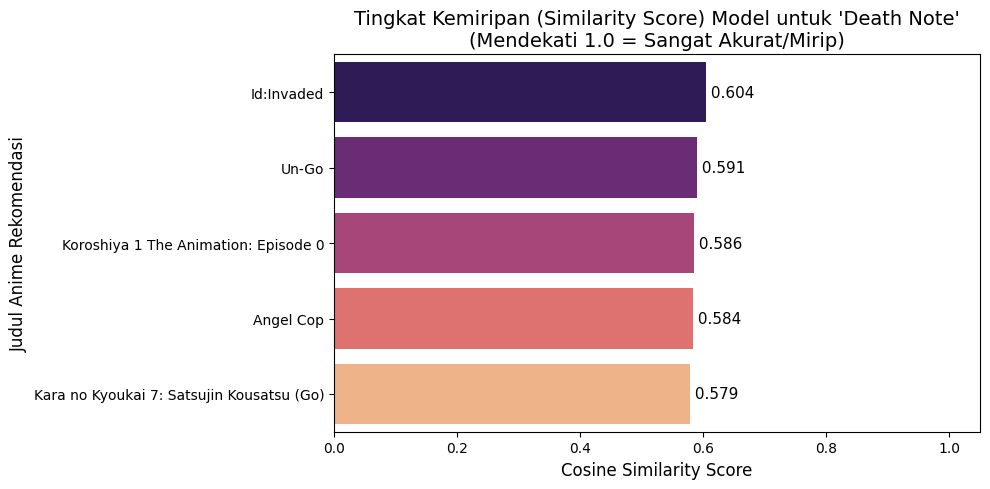

In [ ]:
# Pengujian Sistem dan Melihat "Skor Kemiripan" (Pengganti Akurasi)

judul_kueri = "Death Note"
top_n = 5
hasil_rekomendasi = get_semantic_recommendation(judul_kueri, top_n=top_n)

print(f"Rekomendasi teratas untuk anime: '{judul_kueri}'\n")
print("=" * 70)

# 1. Menampilkan Hasil dengan Persentase Kemiripan
for i, (index, row) in enumerate(hasil_rekomendasi.iterrows(), 1):
    # Mengubah nilai 0-1 menjadi persentase untuk memudahkan pembacaan
    persentase_mirip = row['Similarity_Score'] * 100

    print(f"{i}. Judul    : {row['Name']}")
    print(f"   Akurasi Kemiripan : {row['Similarity_Score']:.4f} ({persentase_mirip:.2f}%)")
    print(f"   Genre    : {row['Genres']}")
    print(f"   Studio   : {row['Studios']}")
    print("-" * 70)

# 2. Visualisasi Skor Kemiripan (Model Evaluation Plot)
plt.figure(figsize=(10, 5))
sns.barplot(
    x='Similarity_Score',
    y='Name',
    data=hasil_rekomendasi,
    palette='magma'
)

# Menambahkan teks skor di ujung bar
for index, value in enumerate(hasil_rekomendasi['Similarity_Score']):
    plt.text(value, index, f" {value:.3f}", va='center', fontsize=11)

plt.title(f"Tingkat Kemiripan (Similarity Score) Model untuk '{judul_kueri}'\n(Mendekati 1.0 = Sangat Akurat/Mirip)", fontsize=14)
plt.xlabel("Cosine Similarity Score", fontsize=12)
plt.ylabel("Judul Anime Rekomendasi", fontsize=12)
plt.xlim(0, 1.05) # Rentang skor dari 0 sampai 1
plt.tight_layout()
plt.show()